<a href="https://colab.research.google.com/github/kimetsu23/Olympic/blob/main/Olympic_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_atletas = pd.read_csv("olympic_athletes.csv")
df_anfitriones = pd.read_csv("olympic_hosts.csv")
df_medallas = pd.read_csv("olympic_medals.csv")
df_resultados = pd.read_csv("olympic_results.csv")

-
-
-
-
-
-
-
-
-
-

# ATLETAS


In [ ]:
df_atletas

,athlete_url,athlete_full_name,games_participations,first_game,athlete_year_birth,athlete_medals,bio
0,https://olympics.com/en/athletes/cooper-woods-...,Cooper WOODS-TOPALOVIC,1,Beijing 2022,2000.0,NaN,NaN
1,https://olympics.com/en/athletes/elofsson,Felix ELOFSSON,2,PyeongChang 2018,1995.0,NaN,NaN
2,https://olympics.com/en/athletes/dylan-walczyk,Dylan WALCZYK,1,Beijing 2022,1993.0,NaN,NaN
3,https://olympics.com/en/athletes/olli-penttala,Olli PENTTALA,1,Beijing 2022,1995.0,NaN,NaN
4,https://olympics.com/en/athletes/reikherd,Dmitriy REIKHERD,1,Beijing 2022,1989.0,NaN,NaN
...,...,...,...,...,...,...,...
75899,https://olympics.com/en/athletes/douglas-weigle,Douglas WEIGLE,1,Innsbruck 1976,1955.0,NaN,\n\n\nKent Weigle competed in ice dancing with...
75900,https://olympics.com/en/athletes/stefania-bertele,Stefania BERTELE,1,Innsbruck 1976,1957.0,NaN,\n\n\nStefania Bertele had the following place...
75901,https://olympics.com/en/athletes/walter-cecconi,Walter CECCONI,1,Innsbruck 1976,1957.0,NaN,\n\n\nWalter Cecconi had the following placeme...
75902,https://olympics.com/en/athletes/susan-kelley,Susan KELLEY,1,Innsbruck 1976,1954.0,NaN,\n\n\nSusie Kelley competed in ice dancing wit...


# Informacion del dataSet: ATLETAS

In [ ]:
df_atletas.info()
# esto es para saber exactamente cuantos elementos NO nulos tiene cada columna de de cada fila, de este data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75904 entries, 0 to 75903
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   athlete_url           75904 non-null  object 
 1   athlete_full_name     75904 non-null  object 
 2   games_participations  75904 non-null  int64  
 3   first_game            75882 non-null  object 
 4   athlete_year_birth    73448 non-null  float64
 5   athlete_medals        15352 non-null  object 
 6   bio                   22842 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 4.1+ MB


In [ ]:
df_atletas.isnull().sum()
# esto es para saber exactamente cuanto elementos NULOS tiene cada columna del data set.

,0
athlete_url,0
athlete_full_name,0
games_participations,0
first_game,22
athlete_year_birth,2456
athlete_medals,60552
bio,53062


In [ ]:
df_atletas.isnull().sum().sum()
# con esto podemos saber cuantas unidades de informacion son de tipo NULO. Al este numero sobrepasar la cantidad de filas perse en el data set, indica que multiples filas tienen mas de 1 solo nulo.

np.int64(116092)

In [ ]:
conteo_nulos_por_fila = df_atletas.isnull().sum(axis=1).value_counts().sort_index()

for nulos, cantidad in conteo_nulos_por_fila.items():
    print(f"Hay {cantidad} filas que tienen {nulos} nulos")
# esto es para saber exactamente la cantidad de nulos que faltan por fila.

Hay 7842 filas que tienen 0 nulos
Hay 21486 filas que tienen 1 nulos
Hay 45125 filas que tienen 2 nulos
Hay 1448 filas que tienen 3 nulos
Hay 3 filas que tienen 4 nulos


In [ ]:
df_atletas.describe()
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / solo se incluyen aqui datos numericos.

,games_participations,athlete_year_birth
count,75904.000000,73448.000000
mean,1.535874,1961.619377
std,0.854563,28.129576
min,0.000000,1836.000000
25%,1.000000,1946.000000
50%,1.000000,1968.000000
75%,2.000000,1983.000000
max,10.000000,2009.000000


In [ ]:
df_atletas.describe(include='all')
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / se incluyeron tambien las columnas *NO* numéricas

,athlete_url,athlete_full_name,games_participations,first_game,athlete_year_birth,athlete_medals,bio
count,75904,75904,75904.000000,75882,73448.000000,15352,22842
unique,75900,75480,NaN,53,NaN,170,22530
top,https://olympics.com/en/athletes/mariana-pajon,Francisco SANCHEZ,NaN,Rio 2016,NaN,\n\n\n1\n\nB\n\n,\n\n\nPersonal Best: Mar – unknown.\n\n\n\n\n\n
freq,2,4,NaN,4111,NaN,4209,110
mean,NaN,NaN,1.535874,NaN,1961.619377,NaN,NaN
std,NaN,NaN,0.854563,NaN,28.129576,NaN,NaN
min,NaN,NaN,0.000000,NaN,1836.000000,NaN,NaN
25%,NaN,NaN,1.000000,NaN,1946.000000,NaN,NaN
50%,NaN,NaN,1.000000,NaN,1968.000000,NaN,NaN
75%,NaN,NaN,2.000000,NaN,1983.000000,NaN,NaN


In [ ]:
# Imputado por la media o mediana
df_atletas['athlete_year_birth'].fillna(df_atletas['athlete_year_birth'].median(), inplace=True)

/tmp/ipython-input-3021175070.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_atletas['athlete_year_birth'].fillna(df_atletas['athlete_year_birth'].median(), inplace=True)


In [ ]:
# ELiminar los null

# Mas o menos mas de la mitad es de los datos de la columna de Bio es null la eliminaremos
df_temp = df_atletas.dropna().drop(columns=["bio"])

df_temp.head()

,athlete_url,athlete_full_name,games_participations,first_game,athlete_year_birth,athlete_medals
16,https://olympics.com/en/athletes/mikael-kingsbury,Mikael KINGSBURY,3,Sochi 2014,1992.0,\n\n\n1\n\nG\n\n\n\n2\n\nS\n\n
36,https://olympics.com/en/athletes/david-wise,David WISE,3,Sochi 2014,1990.0,\n\n\n2\n\nG\n\n\n\n1\n\nS\n\n
44,https://olympics.com/en/athletes/gus-kenworthy,Gus KENWORTHY,3,Sochi 2014,1991.0,\n\n\n1\n\nS\n\n
96,https://olympics.com/en/athletes/jean-frederic...,Jean Frederic CHAPUIS,3,Sochi 2014,1989.0,\n\n\n1\n\nG\n\n
119,https://olympics.com/en/athletes/gu-ailing-eileen,Ailing Eileen GU,1,Beijing 2022,2003.0,\n\n\n2\n\nG\n\n\n\n1\n\nS\n\n


In [ ]:
# Observar los duplicados por atletas
df_atletas.duplicated().sum()

np.int64(0)

In [ ]:
# Eliminar los duplicados y tomar las primeras repuestas
df_atletas.drop_duplicates()

,athlete_url,athlete_full_name,games_participations,first_game,athlete_year_birth,athlete_medals,bio
0,https://olympics.com/en/athletes/cooper-woods-...,Cooper WOODS-TOPALOVIC,1,Beijing 2022,2000.0,NaN,NaN
1,https://olympics.com/en/athletes/elofsson,Felix ELOFSSON,2,PyeongChang 2018,1995.0,NaN,NaN
2,https://olympics.com/en/athletes/dylan-walczyk,Dylan WALCZYK,1,Beijing 2022,1993.0,NaN,NaN
3,https://olympics.com/en/athletes/olli-penttala,Olli PENTTALA,1,Beijing 2022,1995.0,NaN,NaN
4,https://olympics.com/en/athletes/reikherd,Dmitriy REIKHERD,1,Beijing 2022,1989.0,NaN,NaN
...,...,...,...,...,...,...,...
75899,https://olympics.com/en/athletes/douglas-weigle,Douglas WEIGLE,1,Innsbruck 1976,1955.0,NaN,\n\n\nKent Weigle competed in ice dancing with...
75900,https://olympics.com/en/athletes/stefania-bertele,Stefania BERTELE,1,Innsbruck 1976,1957.0,NaN,\n\n\nStefania Bertele had the following place...
75901,https://olympics.com/en/athletes/walter-cecconi,Walter CECCONI,1,Innsbruck 1976,1957.0,NaN,\n\n\nWalter Cecconi had the following placeme...
75902,https://olympics.com/en/athletes/susan-kelley,Susan KELLEY,1,Innsbruck 1976,1954.0,NaN,\n\n\nSusie Kelley competed in ice dancing wit...


In [ ]:
# round Para redondiar por si existe con decimales, Y con la I mayuscula (el de pands)
df_atletas["athlete_year_birth"] = df_atletas["athlete_year_birth"].round().astype("Int64")

In [ ]:
df_atletas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75904 entries, 0 to 75903
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   athlete_url           75904 non-null  object
 1   athlete_full_name     75904 non-null  object
 2   games_participations  75904 non-null  int64 
 3   first_game            75882 non-null  object
 4   athlete_year_birth    75904 non-null  Int64 
 5   athlete_medals        15352 non-null  object
 6   bio                   22842 non-null  object
dtypes: Int64(1), int64(1), object(5)
memory usage: 4.1+ MB


In [ ]:
df_atletas.isnull().sum()
# esto es para saber exactamente cuanto elementos NULOS quedaron en cada columna del data set, despues de las ultimas eliminaciones de todos los nulos y duplicados.

,0
athlete_url,0
athlete_full_name,0
games_participations,0
first_game,22
athlete_year_birth,0
athlete_medals,60552
bio,53062


-
-
-
-
-
-
-
-
-
-

# ANFITRIONES


In [ ]:
df_anfitriones

,game_slug,game_end_date,game_start_date,game_location,game_name,game_season,game_year
0,beijing-2022,2022-02-20T12:00:00Z,2022-02-04T15:00:00Z,China,Beijing 2022,Winter,2022
1,tokyo-2020,2021-08-08T14:00:00Z,2021-07-23T11:00:00Z,Japan,Tokyo 2020,Summer,2020
2,pyeongchang-2018,2018-02-25T08:00:00Z,2018-02-08T23:00:00Z,Republic of Korea,PyeongChang 2018,Winter,2018
3,rio-2016,2016-08-21T21:00:00Z,2016-08-05T12:00:00Z,Brazil,Rio 2016,Summer,2016
4,sochi-2014,2014-02-23T16:00:00Z,2014-02-07T04:00:00Z,Russian Federation,Sochi 2014,Winter,2014
5,london-2012,2012-08-12T19:00:00Z,2012-07-27T07:00:00Z,Great Britain,London 2012,Summer,2012
6,vancouver-2010,2010-02-28T04:00:00Z,2010-02-12T16:00:00Z,Canada,Vancouver 2010,Winter,2010
7,beijing-2008,2008-08-24T12:00:00Z,2008-08-08T00:00:00Z,China,Beijing 2008,Summer,2008
8,turin-2006,2006-02-26T19:00:00Z,2006-02-10T07:00:00Z,Italy,Turin 2006,Winter,2006
9,athens-2004,2004-08-29T18:00:00Z,2004-08-13T06:00:00Z,Greece,Athens 2004,Summer,2004


# Informacion del dataSet: ANFITRIONES

In [ ]:
df_anfitriones.info()
# esto es para saber exactamente cuantos elementos NO nulos tiene cada columna de de cada fila, este data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   game_slug        53 non-null     object
 1   game_end_date    53 non-null     object
 2   game_start_date  53 non-null     object
 3   game_location    53 non-null     object
 4   game_name        53 non-null     object
 5   game_season      53 non-null     object
 6   game_year        53 non-null     int64 
dtypes: int64(1), object(6)
memory usage: 3.0+ KB


In [ ]:
df_anfitriones.isnull().sum()
# esto es para saber exactamente cuanto elementos NULOS tiene cada columna del data set.

,0
game_slug,0
game_end_date,0
game_start_date,0
game_location,0
game_name,0
game_season,0
game_year,0


In [ ]:
df_anfitriones.isnull().sum().sum()
# con esto podemos saber cuantas unidades de informacion son de tipo NULO. Hay 53 filas y ninguna tiene uno o varios nulos, no existen en esta parte del data-set.

np.int64(0)

In [ ]:
conteo_nulos_por_fila = df_anfitriones.isnull().sum(axis=1).value_counts().sort_index()

for nulos, cantidad in conteo_nulos_por_fila.items():
    print(f"Hay {cantidad} filas que tienen {nulos} nulos")
# esto es para saber exactamente la cantidad de nulos que faltan por fila.

Hay 53 filas que tienen 0 nulos


In [ ]:
df_anfitriones.describe()
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / solo se incluyen aqui datos numericos.

,game_year
count,53.000000
mean,1967.547170
std,35.201926
min,1896.000000
25%,1936.000000
50%,1972.000000
75%,1996.000000
max,2022.000000


In [ ]:
df_anfitriones.describe(include='all')
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / se incluyeron tambien las columnas *NO* numéricas

,game_slug,game_end_date,game_start_date,game_location,game_name,game_season,game_year
count,53,53,53,53,53,53,53.000000
unique,53,53,53,26,53,2,NaN
top,beijing-2022,2022-02-20T12:00:00Z,2022-02-04T15:00:00Z,United States,Beijing 2022,Summer,NaN
freq,1,1,1,8,1,29,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1967.547170
std,NaN,NaN,NaN,NaN,NaN,NaN,35.201926
min,NaN,NaN,NaN,NaN,NaN,NaN,1896.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1936.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,1972.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1996.000000


In [ ]:
# Observar los duplicados por anfitriones Y no hay ni uno
df_anfitriones.duplicated(subset=["game_slug"]).sum()

np.int64(0)

-
-
-
-
-
-
-
-
-
-

# MEDALLAS

In [ ]:
df_medallas

,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
0,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/stefania-cons...,Stefania CONSTANTINI,Italy,IT,ITA
1,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/amos-mosaner,Amos MOSANER,Italy,IT,ITA
2,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/kristin-skaslien,Kristin SKASLIEN,Norway,NO,NOR
3,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/magnus-nedreg...,Magnus NEDREGOTTEN,Norway,NO,NOR
4,Curling,beijing-2022,Mixed Doubles,Mixed,BRONZE,GameTeam,Sweden,https://olympics.com/en/athletes/almida-de-val,Almida DE VAL,Sweden,SE,SWE
...,...,...,...,...,...,...,...,...,...,...,...,...
21692,Weightlifting,athens-1896,heavyweight - one hand lift men,Men,SILVER,Athlete,NaN,https://olympics.com/en/athletes/viggo-jensen,Viggo JENSEN,Denmark,DK,DEN
21693,Weightlifting,athens-1896,heavyweight - one hand lift men,Men,BRONZE,Athlete,NaN,NaN,Alexandros Nikolopoulos,Greece,GR,GRE
21694,Weightlifting,athens-1896,heavyweight - two hand lift men,Men,GOLD,Athlete,NaN,https://olympics.com/en/athletes/viggo-jensen,Viggo JENSEN,Denmark,DK,DEN
21695,Weightlifting,athens-1896,heavyweight - two hand lift men,Men,SILVER,Athlete,NaN,https://olympics.com/en/athletes/launceston-el...,Launceston ELLIOT,Great Britain,GB,GBR


# Informacion del dataSet: MEDALLAS

In [ ]:
df_medallas.info()
# esto es para saber exactamente cuantos elementos NO nulos tiene cada columna de de cada fila, este data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21697 entries, 0 to 21696
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   discipline_title       21697 non-null  object
 1   slug_game              21697 non-null  object
 2   event_title            21697 non-null  object
 3   event_gender           21697 non-null  object
 4   medal_type             21697 non-null  object
 5   participant_type       21697 non-null  object
 6   participant_title      6584 non-null   object
 7   athlete_url            17027 non-null  object
 8   athlete_full_name      18073 non-null  object
 9   country_name           21697 non-null  object
 10  country_code           20195 non-null  object
 11  country_3_letter_code  21697 non-null  object
dtypes: object(12)
memory usage: 2.0+ MB


In [ ]:
df_medallas.isnull().sum()
# esto es para saber exactamente cuanto elementos NULOS tiene cada columna del data set.

,0
discipline_title,0
slug_game,0
event_title,0
event_gender,0
medal_type,0
participant_type,0
participant_title,15113
athlete_url,4670
athlete_full_name,3624
country_name,0


In [ ]:
df_medallas.isnull().sum().sum()
# con esto podemos saber cuantas unidades de informacion son de tipo NULO. Al este numero sobrepasar la cantidad de filas perse en el data set, indica que multiples filas tienen mas de 1 solo nulo.

np.int64(24909)

In [ ]:
conteo_nulos_por_fila = df_medallas.isnull().sum(axis=1).value_counts().sort_index()

for nulos, cantidad in conteo_nulos_por_fila.items():
    print(f"Hay {cantidad} filas que tienen {nulos} nulos")
# esto es para saber exactamente la cantidad de nulos que faltan por fila.

Hay 2667 filas que tienen 0 nulos
Hay 13586 filas que tienen 1 nulos
Hay 5009 filas que tienen 2 nulos
Hay 435 filas que tienen 3 nulos


In [ ]:
df_medallas.describe()
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / solo se incluyen aqui datos numericos.

,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
count,21697,21697,21697,21697,21697,21697,6584,17027,18073,21697,20195,21697
unique,86,53,1436,4,3,2,493,12116,12895,154,143,154
top,Athletics,tokyo-2020,Individual men,Men,BRONZE,Athlete,United States team,https://olympics.com/en/athletes/michael-phelp...,Michael PHELPS,United States of America,US,USA
freq,3080,1188,215,13932,7529,15113,523,16,16,3094,3094,3094


In [ ]:
df_medallas.describe(include='all')
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / se incluyeron tambien las columnas *NO* numéricas

,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
count,21697,21697,21697,21697,21697,21697,6584,17027,18073,21697,20195,21697
unique,86,53,1436,4,3,2,493,12116,12895,154,143,154
top,Athletics,tokyo-2020,Individual men,Men,BRONZE,Athlete,United States team,https://olympics.com/en/athletes/michael-phelp...,Michael PHELPS,United States of America,US,USA
freq,3080,1188,215,13932,7529,15113,523,16,16,3094,3094,3094


In [ ]:
# ELiminar los null
df_medallas.dropna()


,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
0,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/stefania-cons...,Stefania CONSTANTINI,Italy,IT,ITA
1,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/amos-mosaner,Amos MOSANER,Italy,IT,ITA
2,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/kristin-skaslien,Kristin SKASLIEN,Norway,NO,NOR
3,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/magnus-nedreg...,Magnus NEDREGOTTEN,Norway,NO,NOR
4,Curling,beijing-2022,Mixed Doubles,Mixed,BRONZE,GameTeam,Sweden,https://olympics.com/en/athletes/almida-de-val,Almida DE VAL,Sweden,SE,SWE
...,...,...,...,...,...,...,...,...,...,...,...,...
21533,Tennis,paris-1900,doubles men,Men,BRONZE,GameTeam,Great Britain team #2,https://olympics.com/en/athletes/harold-serger...,Harold Sergerson MAHONY,Great Britain,GB,GBR
21538,Tennis,paris-1900,mixed doubles mixed,Mixed,GOLD,GameTeam,Great Britain team,https://olympics.com/en/athletes/charlotte-cooper,Charlotte COOPER,Great Britain,GB,GBR
21539,Tennis,paris-1900,mixed doubles mixed,Mixed,GOLD,GameTeam,Great Britain team,https://olympics.com/en/athletes/reginald-fran...,Reginald Frank DOHERTY,Great Britain,GB,GBR
21633,Gymnastics Artistic,athens-1896,team parallel bars men,Men,BRONZE,GameTeam,Ethnikos Gymnastikos Syllogos #2,https://olympics.com/en/athletes/dimitrios-lou...,Dimitrios LOUNDRAS,Greece,GR,GRE


In [ ]:
# Observar los duplicados por medallas
df_medallas.duplicated().sum()

np.int64(0)

In [ ]:
# Eliminar los duplicados y tomar las primeras repuestas
df_medallas.drop_duplicates()

,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
0,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/stefania-cons...,Stefania CONSTANTINI,Italy,IT,ITA
1,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/amos-mosaner,Amos MOSANER,Italy,IT,ITA
2,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/kristin-skaslien,Kristin SKASLIEN,Norway,NO,NOR
3,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/magnus-nedreg...,Magnus NEDREGOTTEN,Norway,NO,NOR
4,Curling,beijing-2022,Mixed Doubles,Mixed,BRONZE,GameTeam,Sweden,https://olympics.com/en/athletes/almida-de-val,Almida DE VAL,Sweden,SE,SWE
...,...,...,...,...,...,...,...,...,...,...,...,...
21692,Weightlifting,athens-1896,heavyweight - one hand lift men,Men,SILVER,Athlete,NaN,https://olympics.com/en/athletes/viggo-jensen,Viggo JENSEN,Denmark,DK,DEN
21693,Weightlifting,athens-1896,heavyweight - one hand lift men,Men,BRONZE,Athlete,NaN,NaN,Alexandros Nikolopoulos,Greece,GR,GRE
21694,Weightlifting,athens-1896,heavyweight - two hand lift men,Men,GOLD,Athlete,NaN,https://olympics.com/en/athletes/viggo-jensen,Viggo JENSEN,Denmark,DK,DEN
21695,Weightlifting,athens-1896,heavyweight - two hand lift men,Men,SILVER,Athlete,NaN,https://olympics.com/en/athletes/launceston-el...,Launceston ELLIOT,Great Britain,GB,GBR


# PREGUNTA #1

# grafica que muestra el pais hasta el 2022, con mas medallas ganadas (sin importar el puesto de la medalla)


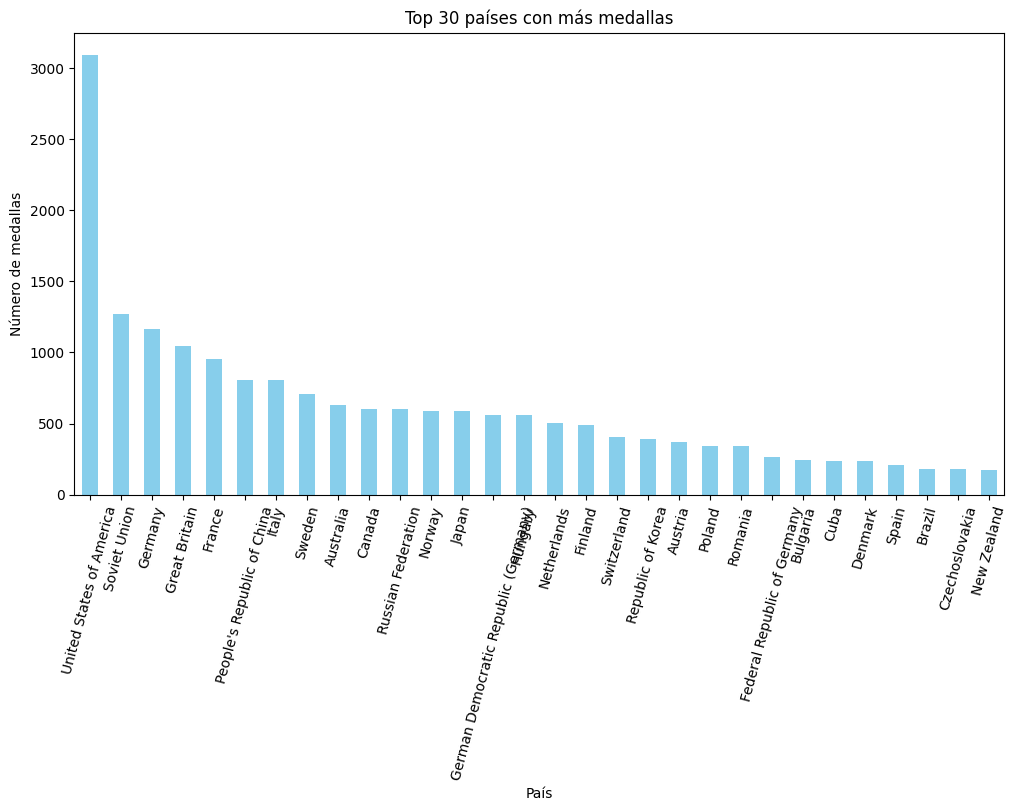

In [ ]:
df_medallas['country_name'].value_counts().head(30).plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title('Top 30 países con más medallas')
plt.xlabel('País')
plt.ylabel('Número de medallas')
plt.xticks(rotation=75)
plt.show()


# PREGUNTA #2

# con esta grafica queremos mostrar, basado en el tipo de medalla, los paises con mas primeros, segundos y terceros lugares en los juegos olimpicos.

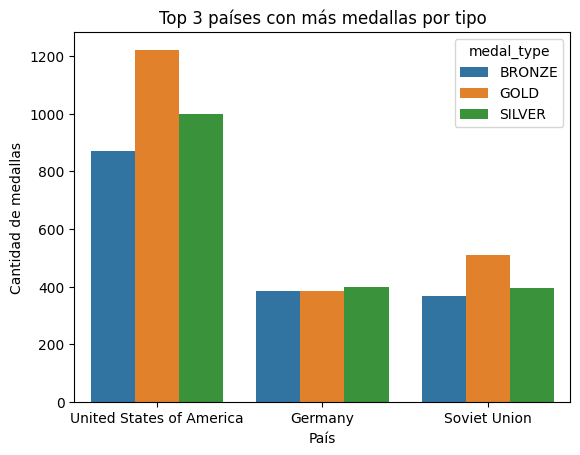

In [ ]:
# agrupamos por país y tipo de medalla
top_medallas = df_medallas.groupby(['country_name', 'medal_type']).size().reset_index(name='count')

# se cogen los 3 países con más medallas de cada tipo
top3_por_tipo = top_medallas.sort_values(['medal_type', 'count'], ascending=[True, False]).groupby('medal_type').head(3)

# graficar con seaborn
sns.barplot(data=top3_por_tipo, x='country_name', y='count', hue='medal_type')
plt.title('Top 3 países con más medallas por tipo')
plt.xlabel('País')
plt.ylabel('Cantidad de medallas')
plt.show()

-
-
-
-
-
-
-
-
-
-

# RESULTADOS

In [ ]:
df_resultados

,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type
0,Curling,Mixed Doubles,beijing-2022,GameTeam,GOLD,"[('Stefania CONSTANTINI', 'https://olympics.co...",False,1,Italy,IT,ITA,NaN,NaN,NaN,NaN
1,Curling,Mixed Doubles,beijing-2022,GameTeam,SILVER,"[('Kristin SKASLIEN', 'https://olympics.com/en...",False,2,Norway,NO,NOR,NaN,NaN,NaN,NaN
2,Curling,Mixed Doubles,beijing-2022,GameTeam,BRONZE,"[('Almida DE VAL', 'https://olympics.com/en/at...",False,3,Sweden,SE,SWE,NaN,NaN,NaN,NaN
3,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Jennifer DODDS', 'https://olympics.com/en/a...",False,4,Great Britain,GB,GBR,NaN,NaN,NaN,NaN
4,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Rachel HOMAN', 'https://olympics.com/en/ath...",False,5,Canada,CA,CAN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162799,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Poland,PL,POL,https://olympics.com/en/athletes/franciszek-bujak,Franciszek BUJAK,NaN,IRM
162800,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Poland,PL,POL,NaN,Henryk Mückenbrunn,NaN,IRM
162801,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Czechoslovakia,CSHH,TCH,NaN,Milda Prokopec,NaN,IRM
162802,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,United States of America,US,USA,NaN,Sigurd Overby,NaN,IRM


# Informacion del dataSet: RESULTADOS

In [ ]:
df_resultados.info()
# esto es para saber exactamente cuantos elementos NO nulos tiene cada columna de de cada fila, este data set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162804 entries, 0 to 162803
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   discipline_title       162804 non-null  object
 1   event_title            162804 non-null  object
 2   slug_game              162804 non-null  object
 3   participant_type       162804 non-null  object
 4   medal_type             20206 non-null   object
 5   athletes               7976 non-null    object
 6   rank_equal             32526 non-null   object
 7   rank_position          158926 non-null  object
 8   country_name           162804 non-null  object
 9   country_code           157768 non-null  object
 10  country_3_letter_code  162804 non-null  object
 11  athlete_url            129991 non-null  object
 12  athlete_full_name      141646 non-null  object
 13  value_unit             78646 non-null   object
 14  value_type             90049 non-null   object
dtype

In [ ]:
df_resultados.isnull().sum()
# esto es para saber exactamente cuanto elementos NULOS tiene cada columna del data set.

,0
discipline_title,0
event_title,0
slug_game,0
participant_type,0
medal_type,142598
athletes,154828
rank_equal,130278
rank_position,3878
country_name,0
country_code,5036


In [ ]:
df_resultados.isnull().sum().sum()
# con esto podemos saber cuantas unidades de informacion son de tipo NULO. Al este numero sobrepasar la cantidad de filas perse en el data set, indica que multiples filas tienen mas de 1 solo nulo.

np.int64(647502)

In [ ]:
conteo_nulos_por_fila = df_resultados.isnull().sum(axis=1).value_counts().sort_index()

for nulos, cantidad in conteo_nulos_por_fila.items():
    print(f"Hay {cantidad} filas que tienen {nulos} nulos")
# esto es para saber exactamente la cantidad de nulos que faltan por fila.

Hay 719 filas que tienen 1 nulos
Hay 15833 filas que tienen 2 nulos
Hay 49658 filas que tienen 3 nulos
Hay 39770 filas que tienen 4 nulos
Hay 39737 filas que tienen 5 nulos
Hay 11341 filas que tienen 6 nulos
Hay 5637 filas que tienen 7 nulos
Hay 108 filas que tienen 8 nulos
Hay 1 filas que tienen 9 nulos


In [ ]:
df_resultados.describe()
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / solo se incluyen aqui datos numericos.

,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type
count,162804,162804,162804,162804,20206,7976,32526,158926,162804,157768,162804,129991,141646,78646,90049
unique,86,1567,53,2,3,6845,2,193,238,213,233,68104,75263,46475,12
top,Athletics,individual mixed,rio-2016,Athlete,BRONZE,"[('LETOT LETOT', 'https://olympics.com/en/athl...",True,9,United States of America,US,USA,https://olympics.com/en/athletes/heikki-savola...,Heikki SAVOLAINEN,same time,TIME
freq,19259,2731,7672,141646,7029,37,23613,8279,11916,11916,11916,34,34,99,43774


In [ ]:
df_resultados.describe(include='all')
# estadísticas básicas de las columnas (promedio, mediana, mínimo, máximo, desviación estándar) / se incluyeron tambien las columnas *NO* numéricas

,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type
count,162804,162804,162804,162804,20206,7976,32526,158926,162804,157768,162804,129991,141646,78646,90049
unique,86,1567,53,2,3,6845,2,193,238,213,233,68104,75263,46475,12
top,Athletics,individual mixed,rio-2016,Athlete,BRONZE,"[('LETOT LETOT', 'https://olympics.com/en/athl...",True,9,United States of America,US,USA,https://olympics.com/en/athletes/heikki-savola...,Heikki SAVOLAINEN,same time,TIME
freq,19259,2731,7672,141646,7029,37,23613,8279,11916,11916,11916,34,34,99,43774


In [ ]:
# ELiminar los null

df_resultados.dropna()

,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type


In [ ]:
# Observar los duplicados por en todas las fijas
df_resultados.duplicated().sum()

np.int64(116)

In [ ]:
# Eliminar los duplicados
df_resultados.drop_duplicates()

,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type
0,Curling,Mixed Doubles,beijing-2022,GameTeam,GOLD,"[('Stefania CONSTANTINI', 'https://olympics.co...",False,1,Italy,IT,ITA,NaN,NaN,NaN,NaN
1,Curling,Mixed Doubles,beijing-2022,GameTeam,SILVER,"[('Kristin SKASLIEN', 'https://olympics.com/en...",False,2,Norway,NO,NOR,NaN,NaN,NaN,NaN
2,Curling,Mixed Doubles,beijing-2022,GameTeam,BRONZE,"[('Almida DE VAL', 'https://olympics.com/en/at...",False,3,Sweden,SE,SWE,NaN,NaN,NaN,NaN
3,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Jennifer DODDS', 'https://olympics.com/en/a...",False,4,Great Britain,GB,GBR,NaN,NaN,NaN,NaN
4,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Rachel HOMAN', 'https://olympics.com/en/ath...",False,5,Canada,CA,CAN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162799,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Poland,PL,POL,https://olympics.com/en/athletes/franciszek-bujak,Franciszek BUJAK,NaN,IRM
162800,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Poland,PL,POL,NaN,Henryk Mückenbrunn,NaN,IRM
162801,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,Czechoslovakia,CSHH,TCH,NaN,Milda Prokopec,NaN,IRM
162802,Ski Jumping,Normal Hill Individual men,chamonix-1924,Athlete,NaN,NaN,NaN,DNS,United States of America,US,USA,NaN,Sigurd Overby,NaN,IRM


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #3
# con esta pregunta quisimos responder la relacion, existente o no, que hay entre si un pais por ser anfitrions esta supuesto a ganar mas medallas, que el mismo pais al momento de no ser anfitrion.

In [ ]:
import pandas as pd
from IPython.display import display

# === CONFIGURACIÓN DE VISUALIZACIÓN ===
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)

# === 1. Contar medallas por país y edición ===
medallas_por_pais_y_juego = (
    df_medallas.groupby(['slug_game', 'country_name'])
    .size()
    .reset_index(name='total_medals')
)

# === 2. Seleccionar el país con más medallas por edición ===
idx_max = medallas_por_pais_y_juego.groupby('slug_game')['total_medals'].idxmax()
top_paises_por_juego = medallas_por_pais_y_juego.loc[idx_max].reset_index(drop=True)

# === 3. Unir con el DataFrame de anfitriones ===
comparacion = top_paises_por_juego.merge(
    df_anfitriones[['game_slug', 'game_location']].drop_duplicates(),
    left_on='slug_game',
    right_on='game_slug',
    how='left'
)

# === 4. Crear indicador: ¿el anfitrión fue el país con más medallas? ===
comparacion['host_won_most_medals'] = (
    comparacion['country_name'].str.strip().str.lower() ==
    comparacion['game_location'].str.strip().str.lower()
)

# === 5. Mostrar la tabla con formato legible ===
display(comparacion[['slug_game', 'game_location', 'country_name', 'total_medals', 'host_won_most_medals']])

# === 6. Resumen con totales y porcentajes ===
total_ediciones = len(comparacion)
ganaron_anfitrion = comparacion['host_won_most_medals'].sum()
no_anfitrion = total_ediciones - ganaron_anfitrion

porc_anfitrion = (ganaron_anfitrion / total_ediciones) * 100
porc_no_anfitrion = (no_anfitrion / total_ediciones) * 100

print("\n🏅 Resumen final:")
print(f"- Total de ediciones analizadas: {total_ediciones}")
print(f"- Países anfitriones que fueron los que más medallas ganaron: {ganaron_anfitrion} ({porc_anfitrion:.2f}%)")
print(f"- Países anfitriones que NO fueron los que más medallas ganaron: {no_anfitrion} ({porc_no_anfitrion:.2f}%)")


,slug_game,game_location,country_name,total_medals,host_won_most_medals
0,albertville-1992,France,Germany,30,False
1,amsterdam-1928,Netherlands,United States of America,58,False
2,antwerp-1920,Belgium,United States of America,96,False
3,athens-1896,Greece,Greece,49,True
4,athens-2004,Greece,United States of America,106,False
5,atlanta-1996,United States,United States of America,106,False
6,barcelona-1992,Spain,United States of America,117,False
7,beijing-2008,China,United States of America,116,False
8,beijing-2022,China,Norway,39,False
9,berlin-1936,Germany,Germany,89,True



🏅 Resumen final:
- Total de ediciones analizadas: 53
- Países anfitriones que fueron los que más medallas ganaron: 8 (15.09%)
- Países anfitriones que NO fueron los que más medallas ganaron: 45 (84.91%)


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #4
# con esta preguntas quisimos responder si la duracion de los juegos se ve afectada por la temporada en la que los mismos se realizan. La misma fue respondida con el promedio de la cantidad de dias que el evento duro en dicha temporada.

In [ ]:
df_anfitriones.assign(
    duration_days=(pd.to_datetime(df_anfitriones["game_end_date"]) - pd.to_datetime(df_anfitriones["game_start_date"])).dt.days
).groupby("game_season")["duration_days"].mean()


,duration_days
game_season,
Summer,42.517241
Winter,12.333333


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #5
# cual ha sido el pais CON MAS MEDALLAS EN CADA JUEGO en la historia de todos los juegos olimpicos?


In [ ]:
# cual ha sido el pais CON MAS MEDALLAS EN CADA JUEGO en la historia de todos los juegos olimpicos ?

(df_medallas
 .groupby(["discipline_title", "country_name", "medal_type"])
 .size()
 .unstack(fill_value=0)
 .assign(total_medals=lambda x: x.sum(axis=1))
 .reset_index()
 .sort_values(["discipline_title", "total_medals"], ascending=[True, False])
 .groupby("discipline_title")
 .first()
 .reset_index())


medal_type,discipline_title,country_name,BRONZE,GOLD,SILVER,total_medals
0,3x3 Basketball,ROC,0,0,2,2
1,Alpine Skiing,Austria,44,40,44,128
2,Archery,Republic of Korea,7,28,9,44
3,Artistic Gymnastics,People's Republic of China,2,3,3,8
4,Artistic Swimming,People's Republic of China,0,0,3,3
...,...,...,...,...,...,...
81,Volleyball,Soviet Union,1,7,4,12
82,Water Motorsports,Great Britain,0,2,0,2
83,Water Polo,Hungary,5,9,3,17
84,Weightlifting,People's Republic of China,8,38,16,62


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #6

# pais con MAS MEDALLAS en juegos solamente POR EQUIPO.


In [ ]:
#pais con MAS MEDALLAS en juegos solamente POR EQUIPO.


# Filtrar solo los juegos en equipo
df_team = df_medallas[df_medallas['participant_type'] == 'GameTeam']

# Agrupar por juego y país, contando las medallas
medallas_por_pais = df_team.groupby(['discipline_title', 'country_name', 'medal_type']).size().unstack(fill_value=0)

# Agregar columna con el total de medallas
medallas_por_pais['Total'] = medallas_por_pais.sum(axis=1)

# Obtener el país con más medallas por juego
resultado = medallas_por_pais.reset_index().sort_values(['discipline_title', 'Total'], ascending=[True, False]).groupby('discipline_title').first().reset_index()

# Renombrar columnas para que sea más legible
resultado = resultado.rename(columns={
    'discipline_title': 'Juego',
    'country_name': 'País',
    'gold': 'Oro',
    'silver': 'Plata',
    'bronze': 'Bronce'
})

# Mostrar resultado
resultado


medal_type,Juego,País,BRONZE,GOLD,SILVER,Total
0,3x3 Basketball,ROC,0,0,2,2
1,Alpine Skiing,Austria,0,1,1,2
2,Archery,Republic of Korea,1,17,1,19
3,Artistic Gymnastics,ROC,0,2,0,2
4,Artistic Swimming,People's Republic of China,0,0,3,3
...,...,...,...,...,...,...
63,Triathlon,France,1,0,0,1
64,Tug of War,Great Britain,1,2,2,5
65,Volleyball,Soviet Union,1,7,4,12
66,Water Motorsports,Great Britain,0,2,0,2


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #7

# pais con MAS MEDALLAS en juegos solamente INDIVIDUALES.


In [ ]:
#pais con MAS MEDALLAS en juegos solamente INDIVIDUALES.

# Filtrar solo los juegos individuales
df_individual = df_medallas[df_medallas['participant_type'] == 'Athlete']

# Agrupar por juego y país, contando las medallas
medallas_por_pais = df_individual.groupby(['discipline_title', 'country_name', 'medal_type']).size().unstack(fill_value=0)

# Agregar columna con el total de medallas
medallas_por_pais['Total'] = medallas_por_pais.sum(axis=1)

# Obtener el país con más medallas por juego
resultado = medallas_por_pais.reset_index().sort_values(['discipline_title', 'Total'], ascending=[True, False]).groupby('discipline_title').first().reset_index()

# Renombrar columnas para que sea más legible
resultado = resultado.rename(columns={
    'discipline_title': 'Juego',
    'country_name': 'País',
    'gold': 'Oro',
    'silver': 'Plata',
    'bronze': 'Bronce'
})

# Mostrar resultado
resultado


medal_type,Juego,País,BRONZE,GOLD,SILVER,Total
0,Alpine Skiing,Austria,44,39,43,126
1,Archery,Republic of Korea,6,11,8,25
2,Artistic Gymnastics,People's Republic of China,1,3,3,7
3,Athletics,United States of America,209,286,255,750
4,Badminton,People's Republic of China,7,9,4,20
...,...,...,...,...,...,...
58,Trampoline,People's Republic of China,6,3,2,11
59,Trampoline Gymnastics,People's Republic of China,0,1,2,3
60,Triathlon,Great Britain,2,2,3,7
61,Weightlifting,People's Republic of China,8,38,16,62


* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *
* * * * * * * * * * *

# PREGUNTA #8

# medallas ganadas por sexo. No se tomaron en cuenta los juegos en equipos, ya que hay juegos en que los equipos pueden ser mixtos de ambos sexos.

In [ ]:
# Filtrar solo los géneros Men y Women
df_genero = df_medallas[df_medallas['event_gender'].isin(['Men', 'Women'])]

# Agrupar por género y tipo de medalla
medallas_genero = df_genero.groupby('event_gender')['medal_type'].value_counts().unstack(fill_value=0)

# Agregar columna con el total de medallas por género
medallas_genero['Total'] = medallas_genero.sum(axis=1)

# Calcular porcentaje de todas las medallas individuales por género
total_medallas = medallas_genero['Total'].sum()
medallas_genero['Porcentaje'] = (medallas_genero['Total'] / total_medallas * 100).round(2)

# Renombrar índices para mayor claridad
medallas_genero.rename(index={'Men': 'Hombres', 'Women': 'Mujeres'}, inplace=True)

# Mostrar resultado
medallas_genero


medal_type,BRONZE,GOLD,SILVER,Total,Porcentaje
event_gender,,,,,
Hombres,4874,4540,4518,13932,68.78
Mujeres,2184,2074,2065,6323,31.22


#PREGUNTA 9

# las disciplinas con más resultados registrados

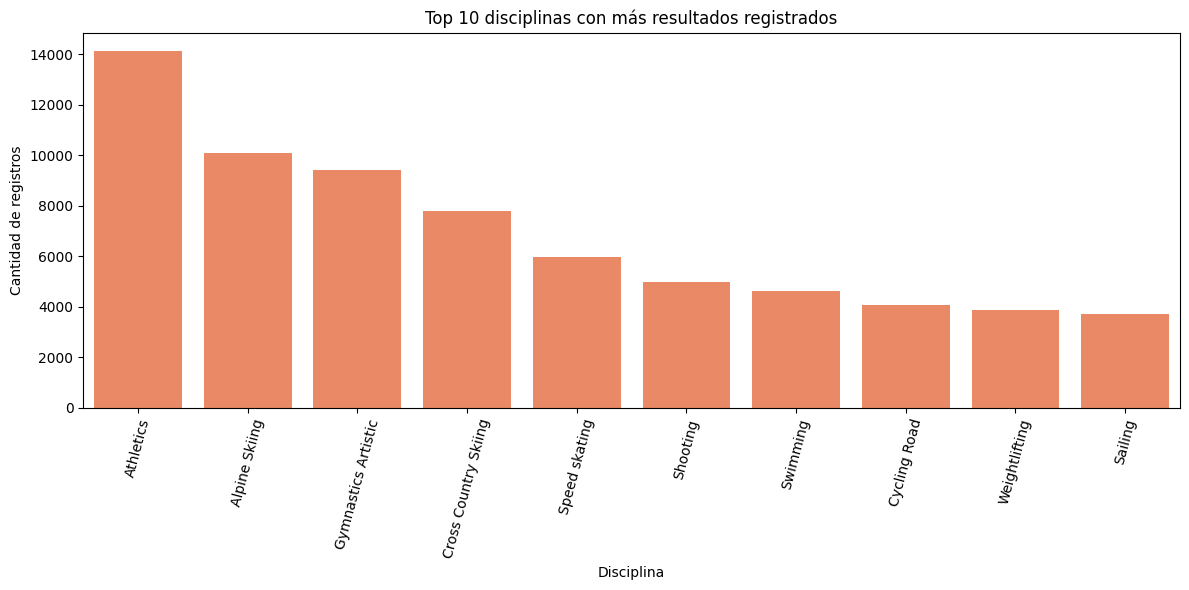

,discipline_title,cantidad_registros
4,Athletics,14150
0,Alpine Skiing,10107
28,Gymnastics Artistic,9425
13,Cross Country Skiing,7806
44,Speed skating,5989
38,Shooting,4974
46,Swimming,4616
16,Cycling Road,4059
52,Weightlifting,3878
37,Sailing,3731


In [ ]:
# Filtrar solo resultados con valores medibles
df_con_valores = df_resultados[df_resultados['value_type'].notna()]

disciplinas_mas_registros = (
    df_con_valores
    .groupby('discipline_title')
    .size()
    .reset_index(name='cantidad_registros')
    .sort_values(by='cantidad_registros', ascending=False)
    .head(10)
)

# Grafica
plt.figure(figsize=(12,6))
sns.barplot(data=disciplinas_mas_registros, x='discipline_title', y='cantidad_registros', color='coral')
plt.title('Top 10 disciplinas con más resultados registrados')
plt.xlabel('Disciplina')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

disciplinas_mas_registros

#PREGUNTA 10

#Cuál país ha participado en más ediciones de los Juegos Olímpicos

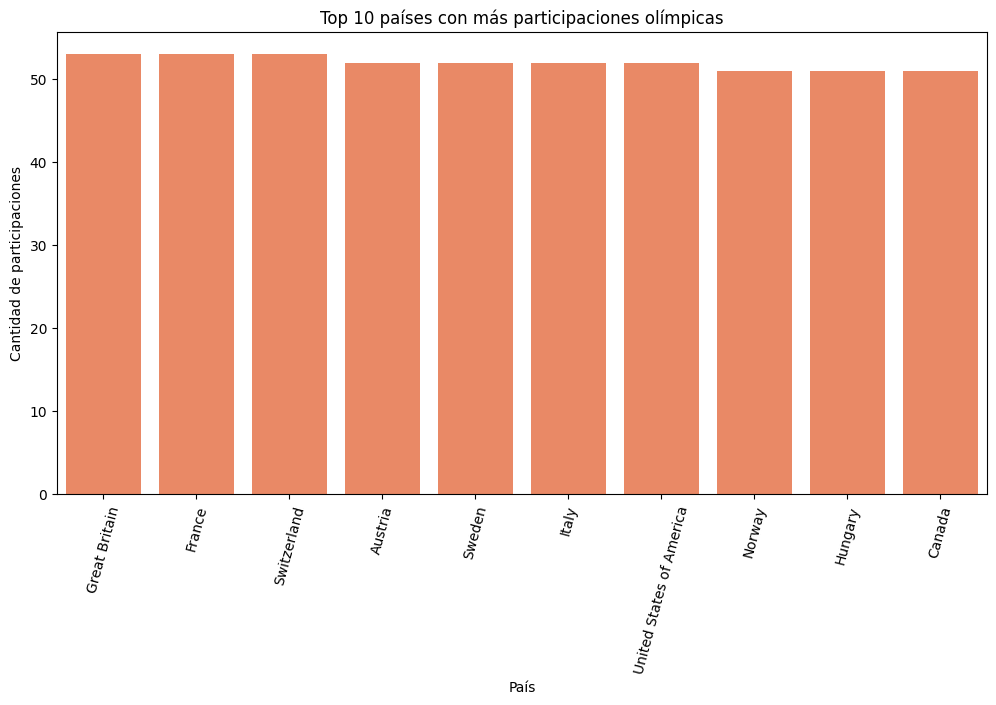

In [ ]:
participaciones = (
    df_resultados.groupby('country_name')['slug_game']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='participaciones')
)

# Mostrar los 10 países con más participaciones
plt.figure(figsize=(12,6))
sns.barplot(data=participaciones.head(10), x='country_name', y='participaciones', color='coral')
plt.title('Top 10 países con más participaciones olímpicas')
plt.xlabel('País')
plt.ylabel('Cantidad de participaciones')
plt.xticks(rotation=75)
plt.show()